<a href="https://colab.research.google.com/github/Joseph-Garvey/cues-ai-hackathon/blob/main/Hackathon_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yes/no data analysis

In [22]:
# YES/NO DATA ANALYSIS
self_results_dishonest = ["yes", "yes", "yes", "no"]


self_honest_correct = results_dishonest.count("yes")
self_honest_incorrect = results_dishonest.count("no")
self_honest_accuracy = self_honest_correct / (self_honest_correct + self_honest_incorrect)

self_dishonest_correct = results_dishonest.count("no")
self_dishonest_incorrect = results_dishonest.count("yes")
self_dishonest_accuracy = self_dishonest_correct / (self_dishonest_correct + self_dishonest_incorrect)

self_accuracy = (self_honest_accuracy + self_dishonest_accuracy) / 2

peer_honest_correct = results_dishonest.count("yes")
peer_honest_incorrect = results_dishonest.count("no")
peer_honest_accuracy = peer_honest_correct / (peer_honest_correct + peer_honest_incorrect)

peer_dishonest_correct = results_dishonest.count("no")
peer_dishonest_incorrect = results_dishonest.count("yes")
peer_dishonest_accuracy = self_dishonest_accuracy = self_dishonest_correct / (self_dishonest_correct + self_dishonest_incorrect)

peer_accuracy = (peer_honest_accuracy + peer_dishonest_accuracy) / 2


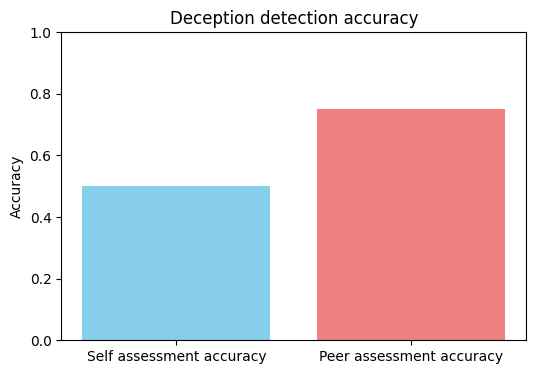

In [23]:
# YES/NO BAR CHART
import matplotlib.pyplot as plt


peer_accuracy = 0.75
self_accuracy = 0.5

values = [self_accuracy, peer_accuracy]
labels = ["Self assessment accuracy", "Peer assessment accuracy"]


# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Deception detection accuracy')
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'colour'

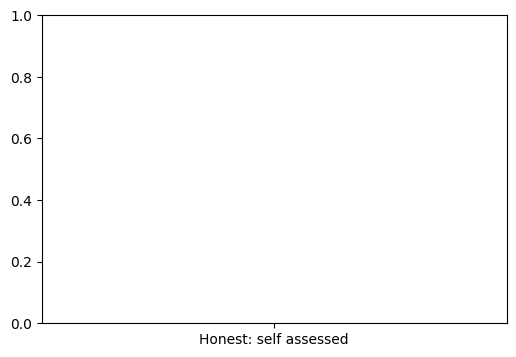

In [21]:
# YES/NO DETAILED BAR CHART

import matplotlib.pyplot as plt


peer_accuracy = 0.75
self_accuracy = 0.5

values = [self_honest_accuracy, self_dishonest_accuracy, peer_honest_accuracy, peer_dishonest_accuracy]
labels = ["Honest: self assessed", "Dishonest: self assessed", "Honest: peer assessed", "Dishonest: peer assessed"]

# Create the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, values, colour=['skyblue', 'lightcoral'])
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.title('Deception detection accuracy')
plt.show()

# 0 to 1 probability data analysis

define 'positive' = 'detected as being deceptive'

define 'negative' = 'detected as being truthful'

0 --> believes it is a lie

1 --> believes it is the truth

In [29]:
import numpy as np

In [ ]:
def clean_data(lists):
  clean_lists = []
  for list in lists:
    clean_list = [float(item.strip("{}")) for item in list]
    clean_lists.append(clean_list)
  return clean_lists

In [85]:
#def functions: find true, false positive rate
def tpr_fpr(honest_assessment, dishonest_assessment, threshold):
  tpr = sum(1 for i in dishonest_assessment if i <= threshold) / len(dishonest_assessment)
  fpr = sum(1 for i in honest_assessment if i <= threshold) / len(honest_assessment)
  return tpr, fpr

def fpr_tpr_graph(honest_assessment, dishonest_assessment, title="Graph"):
  tpr_list = []
  fpr_list = []
  for i in np.linspace(0,1,50):
    tpr, fpr = tpr_fpr(honest_assessment, dishonest_assessment, i)
    tpr_list.append(tpr)
    fpr_list.append(fpr)

  area = trapz(fpr_list, tpr_list)


  fig, ax = plt.subplots(figsize=(8, 6))
  ax.plot(tpr_list, fpr_list, 'o-') # Plot points and lines

  # Shade the area under the curve
  ax.fill_between(tpr_list, fpr_list, color='skyblue', alpha=0.4, label=f'AUC = {area:.3f}')

  ax.set_title(f'{title}: FPR/TPR')
  ax.set_xlabel('False positive rate')
  ax.set_ylabel('True positive rate')
  ax.set_xlim(0,1)
  ax.set_ylim(0,1)

  # Add more gridlines
  ax.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.7)
  ax.minorticks_on()
  ax.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

  ax.legend()
  plt.show()


/tmp/ipython-input-4151117381.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = trapz(fpr_list, tpr_list)


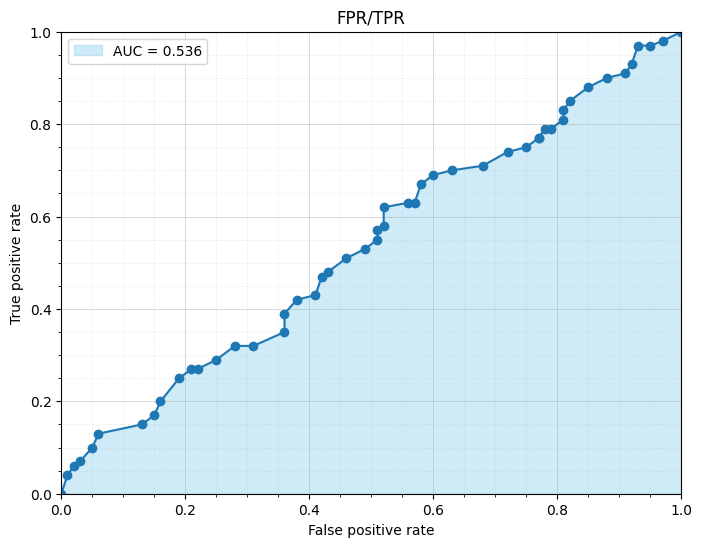

In [84]:
fpr_tpr_graph(array1, array2)

In [ ]:


clean_data = clean_data([self_honest, self_dishonest, peer_honest, peer_dishonest])
fpr_tpr_graph(clean_data[0], clean_data[1], "Self assessment")
fpr_tpr_graph(clean_data[2], clean_data[3], "Peer assessment")